<a href="https://colab.research.google.com/github/KeshavaOfficial/DataScience-Projects/blob/Projects/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/Alphabets_data.csv')

In [4]:
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [6]:
df.describe()


,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


In [7]:
df.isnull().sum()

,0
letter,0
xbox,0
ybox,0
width,0
height,0
onpix,0
xbar,0
ybar,0
x2bar,0
y2bar,0


#No null Values in the Data Set. Now lets assume Alphabets as Y and others and X values which are independent values


In [8]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [9]:
X.head()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [10]:
y.head()

,letter
0,T
1,I
2,D
3,N
4,G


#Now lets Encode the Dependent value using LabelEncoder

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [12]:
y = pd.DataFrame(y)

In [13]:
y

,0
0,19
1,8
2,3
3,13
4,6
...,...
19995,3
19996,2
19997,19
19998,18


#Now lets Standardize the Data in X or Independent Variables


In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [15]:
X_dataset = pd.DataFrame(X_scaled)

In [16]:
X_dataset.columns = X.columns

In [17]:
X_dataset.head()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,-1.057698,0.291877,-1.053277,-0.164704,-1.144013,0.544130,2.365097,-1.714360,0.344994,-0.917071,1.347774,0.034125,-1.305948,-0.219082,-1.438153,0.122911
1,0.510385,1.502358,-1.053277,0.719730,-0.687476,1.531305,-1.075326,0.137561,-0.495072,1.895968,-1.312807,0.514764,-0.448492,-0.219082,0.120081,1.359441
2,-0.012309,1.199738,0.435910,1.161947,1.138672,1.531305,-0.645273,-0.973591,0.344994,0.690380,-1.312807,-0.446513,-0.019764,-0.865626,-0.269477,0.741176
3,1.555774,1.199738,0.435910,0.277513,-0.230939,-0.936631,0.644886,-0.232823,0.344994,-1.720796,-0.932724,0.995402,1.266419,1.074008,-0.659036,0.122911
4,-1.057698,-1.826464,-1.053277,-1.933571,-1.144013,0.544130,-0.645273,0.507945,0.344994,-0.917071,-0.552641,0.514764,-0.877220,-0.865626,0.509640,1.359441


In [18]:
X = X_dataset

#Now lets Split the Data with Train and Test

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

#defining Keras Model

In [21]:
model = Sequential()
model.add(Dense(12, input_dim=16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

#compiling Keras Model

In [22]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
history = model.fit(X, y, epochs=150,validation_split=0.33, batch_size=10)

Epoch 1/150
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.0374 - loss: -1383.9554 - val_accuracy: 0.0361 - val_loss: -23404.5020
Epoch 2/150
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.0393 - loss: -48234.0625 - val_accuracy: 0.0361 - val_loss: -156295.9375
Epoch 3/150
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0395 - loss: -220190.6250 - val_accuracy: 0.0361 - val_loss: -438625.3125
Epoch 4/150
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.0410 - loss: -559360.9375 - val_accuracy: 0.0361 - val_loss: -892783.1250
Epoch 5/150
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0392 - loss: -1059988.2500 - val_accuracy: 0.0361 - val_loss: -1545645.1250
Epoch 6/150
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0403 - loss: -1789445.5000 - val_accuracy: 0.0361 - val_loss: -2412328.0000
Epoch 7/150
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.0398 - loss: -2717173.7500 - val_accuracy: 0.0361 - val_loss: -3520890

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


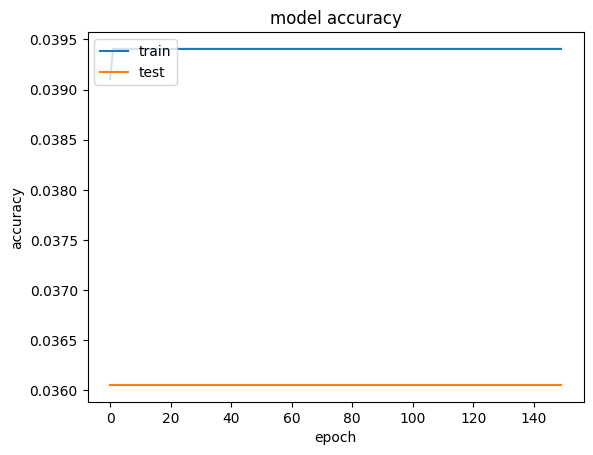

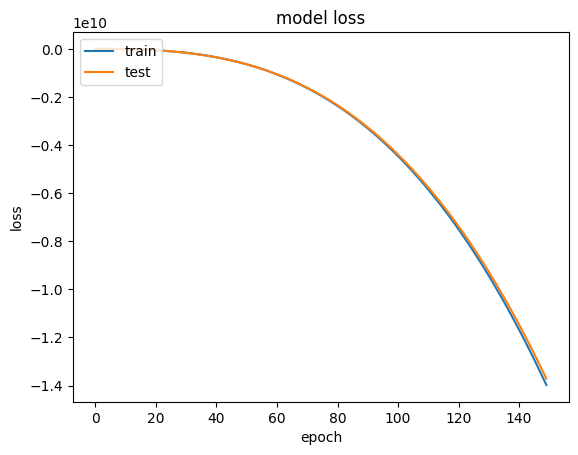

In [24]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#Hyper Parameter Tunning


In [25]:
!pip install tensorflow

In [26]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [47]:
import keras

In [48]:
!pip install scikeras tensorflow

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, KFold

In [71]:
# create model
def create_model():
    model = Sequential()
    model.add(Dense(12, input_dim=16, kernel_initializer='random_uniform', activation='relu'))
    model.add(Dense(8, kernel_initializer='random_uniform', activation='relu'))
    model.add(Dense(1, kernel_initializer='random_uniform', activation='sigmoid'))

    adam=Adam(lr=0.01)
    model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
    return model

In [67]:
!pip install scikeras[tensorflow]


In [69]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold

# Example dataset (Replace with your actual dataset)
X = np.random.rand(100, 16)  # 100 samples, 16 features
y = np.random.randint(0, 2, 100)  # Binary classification labels

# Define hyperparameter grid
batch_sizes = [10, 20, 40]
epochs_list = [10, 50, 100]
learning_rates = [0.001, 0.01, 0.1]

# Function to create model
def create_model(learning_rate):
    model = Sequential([
        Dense(12, input_shape=(16,), kernel_initializer='random_uniform', activation='relu'),
        Dense(8, kernel_initializer='random_uniform', activation='relu'),
        Dense(1, kernel_initializer='random_uniform', activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

# Manual Grid Search
best_score = 0
best_params = None

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for batch_size in batch_sizes:
    for epochs in epochs_list:
        for lr in learning_rates:
            fold_scores = []

            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                model = create_model(lr)
                model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, verbose=0)

                # Evaluate on validation set
                _, accuracy = model.evaluate(X_val, y_val, verbose=0)
                fold_scores.append(accuracy)

            avg_score = np.mean(fold_scores)

            if avg_score > best_score:
                best_score = avg_score
                best_params = {"batch_size": batch_size, "epochs": epochs, "learning_rate": lr}

            print(f"batch_size={batch_size}, epochs={epochs}, learning_rate={lr} --> Accuracy: {avg_score:.4f}")

# Print the best parameters
print("\nBest Parameters Found:", best_params)


batch_size=10, epochs=10, learning_rate=0.001 --> Accuracy: 0.5600
batch_size=10, epochs=10, learning_rate=0.01 --> Accuracy: 0.5600
batch_size=10, epochs=10, learning_rate=0.1 --> Accuracy: 0.5600
batch_size=10, epochs=50, learning_rate=0.001 --> Accuracy: 0.5400
batch_size=10, epochs=50, learning_rate=0.01 --> Accuracy: 0.5500
batch_size=10, epochs=50, learning_rate=0.1 --> Accuracy: 0.5600
batch_size=10, epochs=100, learning_rate=0.001 --> Accuracy: 0.5400
batch_size=10, epochs=100, learning_rate=0.01 --> Accuracy: 0.5400
batch_size=10, epochs=100, learning_rate=0.1 --> Accuracy: 0.5600
batch_size=20, epochs=10, learning_rate=0.001 --> Accuracy: 0.5600
batch_size=20, epochs=10, learning_rate=0.01 --> Accuracy: 0.5600
batch_size=20, epochs=10, learning_rate=0.1 --> Accuracy: 0.5500
batch_size=20, epochs=50, learning_rate=0.001 --> Accuracy: 0.5600
batch_size=20, epochs=50, learning_rate=0.01 --> Accuracy: 0.5300
batch_size=20, epochs=50, learning_rate=0.1 --> Accuracy: 0.5600
batch_s

In [79]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.7 MB/s eta 0:00:00


In [85]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, classification_report

y_pred_basic = np.argmax(model.predict(X_test), axis=1)
print("Basic Model Accuracy:", accuracy_score(y_test, y_pred_basic))
print(classification_report(y_test, y_pred_basic))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Basic Model Accuracy: 0.03725
              precision    recall  f1-score   support

           0       0.04      1.00      0.07       149
           1       0.00      0.00      0.00       153
           2       0.00      0.00      0.00       137
           3       0.00      0.00      0.00       156
           4       0.00      0.00      0.00       141
           5       0.00      0.00      0.00       140
           6       0.00      0.00      0.00       160
           7       0.00      0.00      0.00       144
           8       0.00      0.00      0.00       146
           9       0.00      0.00      0.00       149
          10       0.00      0.00      0.00       130
          11       0.00      0.00      0.00       155
          12       0.00      0.00      0.00       168
          13       0.00      0.00      0.00       151
          14       0.00      0.00      0.00       145
          15       0.00      0.00      0.00       173
          

Text(0.5, 1.0, 'Confusion Matrix')

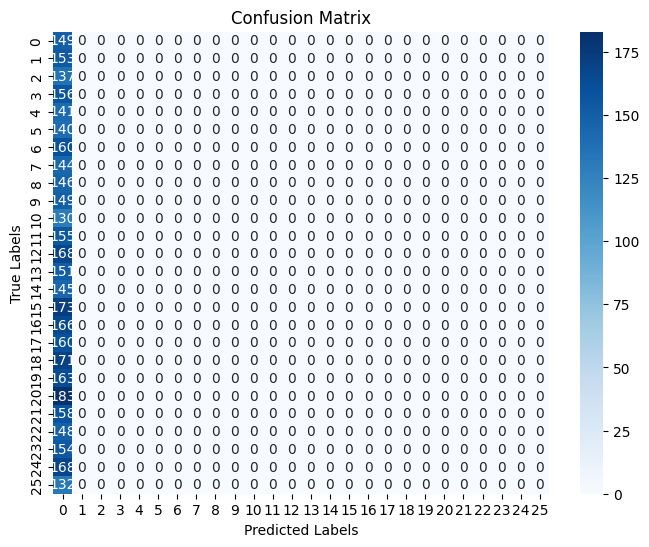

In [92]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix and store in a variable (e.g., cm)
cm = confusion_matrix(y_test, y_pred_basic)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues") # Use cm here
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

In [81]:
import keras_tuner as kt

# Define the build_model function
def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units', min_value=32, max_value=512, step=32),
                    activation='relu', input_dim=16))  # Input layer
    model.add(Dense(1, activation='sigmoid'))  # Output layer
    model.compile(optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Now you can use the tuner with the defined build_model function
tuner = kt.RandomSearch(
    build_model,  # Pass the function here
    objective='val_accuracy',
    max_trials=5,
    directory='hyperparam_tuning',
    project_name='alphabet_classification'
)

tuner.search(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

# ... (rest of the code)

Trial 5 Complete [00h 00m 18s]
val_accuracy: 0.04125000163912773

Best val_accuracy So Far: 0.05649999901652336
Total elapsed time: 00h 01m 32s
